In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from dotenv import load_dotenv
from langchain_groq import ChatGroq


c:\Users\ACER\OneDrive\Desktop\MACHINE LEARNING\Langraph\myvenv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
class QuadraticState(TypedDict):
    a:int
    b:int
    c:int
    discriminant:float
    result:str
    equation:str            

In [3]:
def show_equation(state:QuadraticState):
      equation=f"{state["a"]}X2{state["b"]}X{state["c"]}"
      return {"equation":equation}

In [4]:
def calculate_discriminant(state:QuadraticState):
    #    calculating discriminant value
    discriminant=state["b"]**2-(4*state["a"]*state["c"])
    return {"discriminant":discriminant}

In [5]:
def real_roots(state:QuadraticState):
    root1=(-state["b"]+state["discriminant"]**0.5)/2*state["a"]
    root2=(-state["b"]-state["discriminant"]**0.5)/2*state["a"]
    
    result=f"the roots of the {state["equation"]} are {root1} and {root2}."
    return {"result":result}

In [6]:
def no_real_roots(state:QuadraticState):
    result=f"no real roots"
    return {"result":result}

In [7]:
def two_equal_roots(state:QuadraticState):
    root=(-state["b"])/2*state["a"]
    result=f"the equation:{state["equation"]} has two equal roots i.e, {root}"
    return {"result":result}

In [14]:
def check_condition(state:QuadraticState)->Literal["real_roots","no_real_roots","two_equal_roots"]:
    if state["discriminant"]>0:
        return "real_roots"
    elif state["discriminant"]==0:
        return "two_equal_roots"
    else :
        return "no_real_roots"

In [15]:
graph=StateGraph(QuadraticState)

graph.add_node("show_equation",show_equation)
graph.add_node("calculate_discriminant",calculate_discriminant)
graph.add_node("real_roots",real_roots)
graph.add_node("no_real_roots",no_real_roots)
graph.add_node("two_equal_roots",two_equal_roots)



graph.add_edge(START,"show_equation")
graph.add_edge("show_equation","calculate_discriminant")

graph.add_conditional_edges("calculate_discriminant",check_condition)  # important line 

graph.add_edge("real_roots",END)
graph.add_edge("two_equal_roots",END)
graph.add_edge("no_real_roots",END)


In [16]:
workflow=graph.compile()

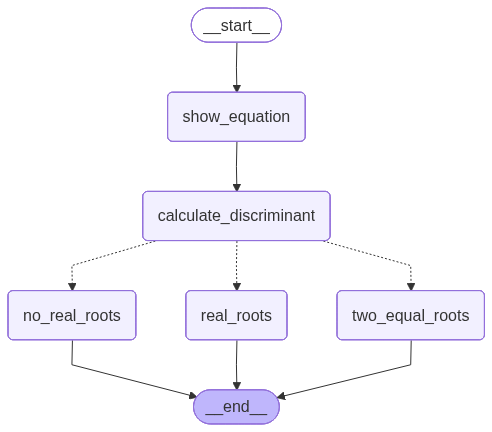

In [17]:
workflow

In [18]:
initial_state={"a":5,"b":-3,"c":-2}

In [19]:
output_state=workflow.invoke(initial_state)

In [20]:
output_state

{'a': 5,
 'b': -3,
 'c': -2,
 'discriminant': 49,
 'result': 'the roots of the 5X2-3X-2 are 25.0 and -10.0.',
 'equation': '5X2-3X-2'}